In [11]:
import pandas as pd 
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.DataFrame(pd.read_csv(r'C:\Users\MSI\Desktop\Heart Disease\Data\data.csv'))
# Convert column to string and strip extra spaces so that we encode them
df["Heart Disease"] = df["Heart Disease"].astype(str).str.strip()
# Remove leading/trailing spaces and standardize
df["Heart Disease"] = df["Heart Disease"].map({"Absence": 0, "Presence": 1})
df.head()
#we are going to drop around 65K samples with label 0 in order to balance the dataset .
rows_with_0 = df[df["Heart Disease"] == 0]
rows_to_drop = rows_with_0.sample(65000, random_state=42)  # random 65000
df = df.drop(rows_to_drop.index)
df["Heart Disease"].value_counts()

Heart Disease
0    282546
1    282454
Name: count, dtype: int64

In [ ]:
#Adding More features to our model and re-evaluating it
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])



Accuracy: 0.8773008849557522
               precision    recall  f1-score   support

   No Disease       0.88      0.88      0.88     56509
Heart Disease       0.88      0.87      0.88     56491

     accuracy                           0.88    113000
    macro avg       0.88      0.88      0.88    113000
 weighted avg       0.88      0.88      0.88    113000



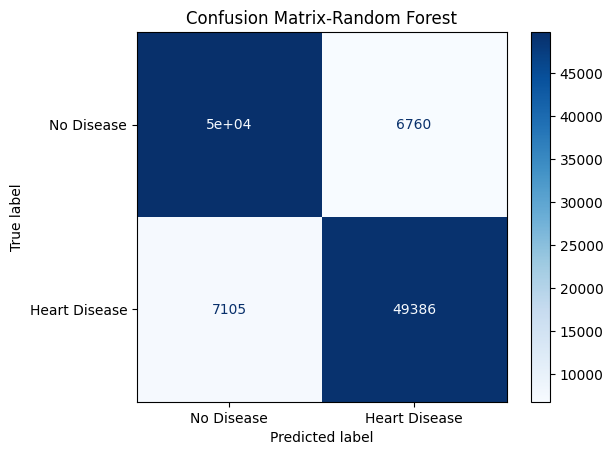

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix-Random Forest")
plt.show()

c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [18:16:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.8854

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.88      0.89      0.89     56509
Heart Disease       0.89      0.88      0.88     56491

     accuracy                           0.89    113000
    macro avg       0.89      0.89      0.89    113000
 weighted avg       0.89      0.89      0.89    113000



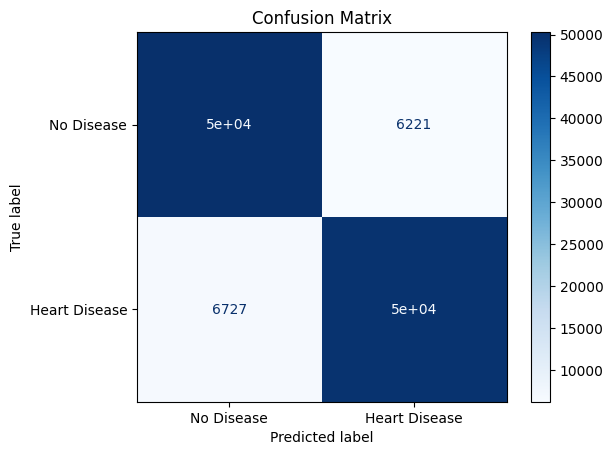

In [13]:
from xgboost import XGBClassifier

# -----------------------------
# 4️⃣ Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

# -----------------------------
# 5️⃣ Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

# -----------------------------
# 6️⃣ Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
